# HU003 - Pipeline reproducible del entorno BattleZone

Notebook nuevo para validar el contrato estable de entorno y preprocessing de `ALE/BattleZone-v5`.

Alcance: configuracion, factory unica, preprocessing visual, frame stack, seeds, smoke test y autovalidaciones. No implementa agente ni selecciona algoritmo.

In [1]:
# GitHub = codigo; /content = ejecucion efimera; Drive = artefactos.
import builtins
import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/j-mauro-r/reinforcement_learning_reto_1.git"
COLAB_ROOT = Path("/content/reinforcement_learning_reto_1")
# Development default while PR #36 is open.
# After merge, switch REQUESTED_REF to "main" and pin an immutable
# REQUESTED_COMMIT for formal/final executions.

REQUESTED_REF = "feature/battlezone-hu011c-evaluacion-academica"
REQUESTED_COMMIT = "0e4be639b2cb1728739e18dba51e9bc85681e7cd"
INSTALL_DEPENDENCIES = True

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    if not (COLAB_ROOT / ".git").exists():
        subprocess.run(["git", "clone", REPO_URL, str(COLAB_ROOT)], check=True)
    elif subprocess.check_output(["git", "status", "--porcelain"], cwd=COLAB_ROOT, text=True).strip():
        raise RuntimeError("Colab execution copy is dirty; restart the runtime.")
    subprocess.run(["git", "fetch", "--prune", "origin"], cwd=COLAB_ROOT, check=True)
    target = REQUESTED_COMMIT or f"origin/{REQUESTED_REF}"
    provisional_sha = subprocess.check_output(["git", "rev-parse", "--verify", f"{target}^{{commit}}"], cwd=COLAB_ROOT, text=True).strip()
    current_sha = subprocess.check_output(["git", "rev-parse", "HEAD"], cwd=COLAB_ROOT, text=True).strip()
    loaded_src = [name for name in sys.modules if name == "src" or name.startswith("src.")]
    previous_sha = getattr(builtins, "_BATTLEZONE_BOOTSTRAP_STATE", {}).get("resolved_sha")
    if loaded_src and (current_sha != provisional_sha or (previous_sha and previous_sha != provisional_sha)):
        raise RuntimeError("Bootstrap target changed. Restart the Colab runtime and execute from the first cell.")
    subprocess.run(["git", "checkout", "--detach", provisional_sha], cwd=COLAB_ROOT, check=True)
    REPO_ROOT = COLAB_ROOT
else:
    REPO_ROOT = Path(subprocess.check_output(["git", "rev-parse", "--show-toplevel"], text=True).strip())

PROJECT_DIR = REPO_ROOT / "3_BattleZone"
sys.path.insert(0, str(PROJECT_DIR))  # bootstrap loader only; helper normalizes it
import src.execution_bootstrap as execution_bootstrap_module
bootstrap_source = Path(execution_bootstrap_module.__file__).resolve()
if (PROJECT_DIR / "src").resolve() not in bootstrap_source.parents:
    raise RuntimeError(f"Unexpected bootstrap source: {bootstrap_source}. Restart the Colab runtime and execute from the first cell.")
from src.execution_bootstrap import install_project_requirements, prepare_execution_environment, validate_cuda_runtime, verify_environment_import
bootstrap = prepare_execution_environment(REQUESTED_REF, REQUESTED_COMMIT, REPO_URL, COLAB_ROOT)
if INSTALL_DEPENDENCIES:
    install_project_requirements(bootstrap.requirements_path)
environment_source = verify_environment_import(bootstrap)
REPO_ROOT, PROJECT_DIR = bootstrap.repo_root, bootstrap.battlezone_dir
print("EXECUTED_SHA:", bootstrap.resolved_sha)
print("src.execution_bootstrap:", bootstrap_source)
print("src.environment:", environment_source)

BattleZone execution bootstrap
  runtime: Google Colab
  repository: /content/reinforcement_learning_reto_1
  battlezone_dir: /content/reinforcement_learning_reto_1/3_BattleZone
  requested_ref: feature/battlezone-hu011c-evaluacion-academica
  requested_commit: 0e4be639b2cb1728739e18dba51e9bc85681e7cd
  resolved_sha: 0e4be639b2cb1728739e18dba51e9bc85681e7cd
  requirements: /content/reinforcement_learning_reto_1/3_BattleZone/requirements.txt
src.environment import source: /content/reinforcement_learning_reto_1/3_BattleZone/src/environment.py
EXECUTED_SHA: 0e4be639b2cb1728739e18dba51e9bc85681e7cd
src.execution_bootstrap: /content/reinforcement_learning_reto_1/3_BattleZone/src/execution_bootstrap.py
src.environment: /content/reinforcement_learning_reto_1/3_BattleZone/src/environment.py


In [2]:
import json
from pathlib import Path

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.environment import (
    build_candidate_config,
    create_battlezone_env,
    get_contract,
    load_config,
    preprocess_frame,
    seed_environment,
    validate_final_contract,
    validate_raw_contract,
    verify_single_frameskip,
)
from src.utils import get_git_commit, get_runtime_info

CONFIG_PATH = PROJECT_DIR / "configs" / "battlezone_config.yaml"
config = load_config(CONFIG_PATH)
runtime_info = get_runtime_info()

display(pd.DataFrame([runtime_info]).T.rename(columns={0: "value"}))
print("Git commit:", get_git_commit(PROJECT_DIR.parent))

# Hard gate: a formal HU011 run must keep Colab's CUDA-enabled PyTorch build.
import torch
cuda_available = torch.cuda.is_available()
cuda_version = torch.version.cuda
gpu_name = torch.cuda.get_device_name(0) if cuda_available else None
print("PYTORCH:", torch.__version__)
print("DEVICE:", "cuda" if cuda_available else "cpu")
print("CUDA AVAILABLE:", cuda_available)
print("CUDA VERSION:", cuda_version)
print("GPU NAME:", gpu_name)
validate_cuda_runtime(
    torch_version=torch.__version__, cuda_available=cuda_available,
    cuda_version=cuda_version, gpu_name=gpu_name, required=IN_COLAB,
)

# Drive is mounted only for durable artifacts; code continues to execute from /content.
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    if not Path("/content/drive/MyDrive").exists():
        raise RuntimeError("Google Drive mount is unavailable: /content/drive/MyDrive")
    PERSISTENT_ROOT = Path("/content/drive/MyDrive/reinforcement_learning/battlezone")
else:
    PERSISTENT_ROOT = Path("/tmp/battlezone_artifacts")
PERSISTENT_ROOT.mkdir(parents=True, exist_ok=True)
write_probe = PERSISTENT_ROOT / ".hu011_write_probe"
write_probe.write_text("writable", encoding="utf-8")
PERSISTENT_ROOT_WRITABLE = write_probe.read_text(encoding="utf-8") == "writable"
write_probe.unlink()
if not PERSISTENT_ROOT_WRITABLE:
    raise RuntimeError(f"Persistent root is not writable: {PERSISTENT_ROOT}")
print("PERSISTENT_ROOT:", PERSISTENT_ROOT)
print("PERSISTENT_ROOT_WRITABLE:", PERSISTENT_ROOT_WRITABLE)

Mounted at /content/drive
PERSISTENT_ROOT: /content/drive/MyDrive/reinforcement_learning/battlezone
PERSISTENT_ROOT_WRITABLE: True


In [3]:
# Configuracion centralizada de HU003.
pd.DataFrame([{
    "env_id": config["environment"]["env_id"],
    "seed": config["environment"]["seed"],
    "mode": config["environment"]["mode"],
    "difficulty": config["environment"]["difficulty"],
    "obs_type": config["environment"]["obs_type"],
    "frameskip": config["environment"]["frameskip"],
    "sticky_actions": config["environment"]["repeat_action_probability"],
    "pipeline": config["preprocessing"]["pipeline_name"],
    "color_mode": config["preprocessing"]["color_mode"],
    "resize": f'{config["preprocessing"]["resize"]["height"]}x{config["preprocessing"]["resize"]["width"]}',
    "crop": config["preprocessing"]["crop"]["enabled"],
    "frame_stack": config["preprocessing"]["frame_stack"],
    "dtype": config["preprocessing"]["dtype"],
    "reward_transform": config["preprocessing"]["reward_transform"],
}])

,env_id,seed,mode,difficulty,obs_type,frameskip,sticky_actions,pipeline,color_mode,resize,crop,frame_stack,dtype,reward_transform
0,ALE/BattleZone-v5,20260903,1,0,rgb,4,0.25,battlezone_rgb_128_stack4_no_crop,rgb,128x128,False,4,uint8,none


In [4]:
# Contrato raw controlado antes del preprocessing.
env_cfg = config["environment"]
raw_env = gym.make(
    env_cfg["env_id"],
    obs_type=env_cfg["obs_type"],
    frameskip=env_cfg["frameskip"],
    repeat_action_probability=env_cfg["repeat_action_probability"],
    mode=env_cfg["mode"],
    difficulty=env_cfg["difficulty"],
    render_mode=None,
)
try:
    raw_frame, raw_info = raw_env.reset(seed=env_cfg["seed"])
    seed_environment(raw_env, env_cfg["seed"])
    validate_raw_contract(raw_env, config)
    raw_contract = {
        "observation_space": str(raw_env.observation_space),
        "action_space": str(raw_env.action_space),
        "action_meanings_count": len(raw_env.unwrapped.get_action_meanings()),
        "raw_shape": tuple(raw_frame.shape),
        "raw_dtype": str(raw_frame.dtype),
        "raw_min": int(raw_frame.min()),
        "raw_max": int(raw_frame.max()),
        "reset_info_keys": sorted(raw_info.keys()),
    }
finally:
    raw_env.close()

pd.DataFrame([raw_contract]).T.rename(columns={0: "value"})

,value
observation_space,"Box(0, 255, (210, 160, 3), uint8)"
action_space,Discrete(18)
action_meanings_count,18
raw_shape,"(210, 160, 3)"
raw_dtype,uint8
raw_min,0
raw_max,236
reset_info_keys,"[episode_frame_number, frame_number, lives, se..."


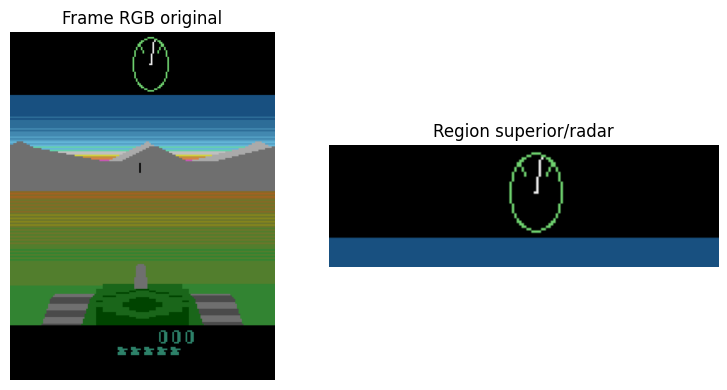

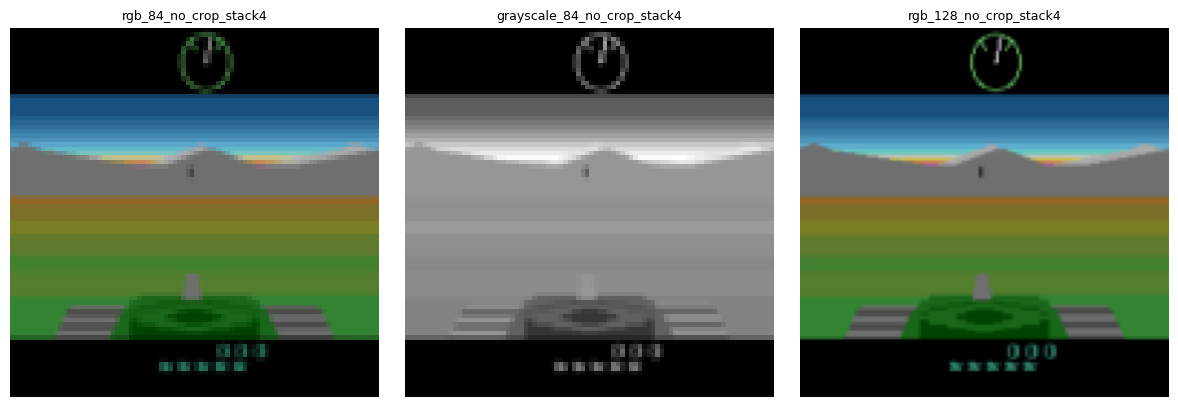

,candidate,color_mode,resize,crop_enabled,frame_stack,single_frame_shape,dtype,bytes_single_frame,reason
0,rgb_84_no_crop_stack4,rgb,84x84,False,4,"(84, 84, 3)",uint8,21168,Atari common-size comparison; not selected bec...
1,grayscale_84_no_crop_stack4,grayscale,84x84,False,4,"(84, 84)",uint8,7056,Channel-reduced comparison; not selected becau...
2,rgb_128_no_crop_stack4,rgb,128x128,False,4,"(128, 128, 3)",uint8,49152,Selected compromise: preserves radar and color...


In [5]:
# Evidencia visual: frame original, radar y candidatos de preprocessing.
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(raw_frame)
axes[0].set_title("Frame RGB original")
axes[0].axis("off")
radar_region = raw_frame[:50, :, :]
axes[1].imshow(radar_region)
axes[1].set_title("Region superior/radar")
axes[1].axis("off")
plt.tight_layout()
plt.show()

candidate_rows = []
processed_candidates = []
for candidate in config["validation"]["candidate_preprocessing"]:
    candidate_cfg = build_candidate_config(config, candidate)
    processed = preprocess_frame(raw_frame, candidate_cfg)
    processed_candidates.append((candidate, processed))
    candidate_rows.append({
        "candidate": candidate["name"],
        "color_mode": candidate["color_mode"],
        "resize": f'{candidate["resize"][1]}x{candidate["resize"][0]}',
        "crop_enabled": candidate["crop_enabled"],
        "frame_stack": candidate["frame_stack"],
        "single_frame_shape": tuple(processed.shape),
        "dtype": str(processed.dtype),
        "bytes_single_frame": processed.nbytes,
        "reason": candidate["rationale"],
    })

fig, axes = plt.subplots(1, len(processed_candidates), figsize=(12, 4))
for ax, (candidate, processed) in zip(axes, processed_candidates):
    cmap = "gray" if processed.ndim == 2 else None
    ax.imshow(processed, cmap=cmap)
    ax.set_title(candidate["name"], fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

pd.DataFrame(candidate_rows)

In [6]:
# Factory unica: contrato final seleccionado.
env = create_battlezone_env(config, mode="train", seed=env_cfg["seed"])
try:
    final_obs, final_info = env.reset(seed=env_cfg["seed"])
    seed_environment(env, env_cfg["seed"])
    validate_final_contract(env, config, final_obs)
    final_contract = get_contract(env, config)
finally:
    env.close()

pd.DataFrame([final_contract]).T.rename(columns={0: "value"})

,value
env_id,ALE/BattleZone-v5
mode,1
difficulty,0
frameskip,4
repeat_action_probability,0.25
action_space,Discrete(18)
action_meanings,"[NOOP, FIRE, UP, RIGHT, LEFT, DOWN, UPRIGHT, U..."
pipeline_name,battlezone_rgb_128_stack4_no_crop
color_mode,rgb
resize,"[128, 128]"


In [7]:
# Smoke test corto con politica aleatoria del action space, sin entrenamiento.
print("ENVIRONMENT_SMOKE_TEST — THIS IS NOT HU011 TRAINING")
env = create_battlezone_env(config, mode="train", seed=env_cfg["seed"] + 1)
smoke_rows = []
try:
    obs, info = env.reset(seed=env_cfg["seed"] + 1)
    seed_environment(env, env_cfg["seed"] + 1)
    for step in range(config["validation"]["smoke_steps"]):
        action = int(env.action_space.sample())
        obs, reward, terminated, truncated, info = env.step(action)
        smoke_rows.append({
            "step": step + 1,
            "action": action,
            "reward": float(reward),
            "terminated": bool(terminated),
            "truncated": bool(truncated),
            "shape": tuple(obs.shape),
            "dtype": str(obs.dtype),
            "frame_number": info.get("frame_number") if isinstance(info, dict) else None,
        })
        if terminated or truncated:
            break
finally:
    env.close()

smoke_df = pd.DataFrame(smoke_rows)
display(smoke_df.head())
print("Smoke steps:", len(smoke_df))

ENVIRONMENT_SMOKE_TEST — THIS IS NOT HU011 TRAINING


,step,action,reward,terminated,truncated,shape,dtype,frame_number
0,1,12,0.0,False,False,"(4, 128, 128, 3)",uint8,4
1,2,15,0.0,False,False,"(4, 128, 128, 3)",uint8,8
2,3,13,0.0,False,False,"(4, 128, 128, 3)",uint8,12
3,4,15,0.0,False,False,"(4, 128, 128, 3)",uint8,16
4,5,14,0.0,False,False,"(4, 128, 128, 3)",uint8,20


Smoke steps: 32


In [8]:
# Frameskip efectivo: el wrapper stack no repite acciones; ALE avanza 4 frames por step.
env = create_battlezone_env(config, mode="train", seed=env_cfg["seed"] + 2)
try:
    frameskip_report = verify_single_frameskip(env, config, steps=3)
finally:
    env.close()

pd.DataFrame([frameskip_report]).T.rename(columns={0: "value"})

,value
wrapper_chain,"[FrameStackObservation, BattleZonePreprocessOb..."
frame_numbers,"[0, 4, 8, 12]"
frame_deltas,"[4, 4, 4]"
expected_delta,4
has_action_repeat_wrapper,False
counter_check_passed,True


In [9]:
# Paridad train/eval: mismo contrato perceptual y action space, seeds distintas.
train_env = create_battlezone_env(config, mode="train", seed=111)
eval_env = create_battlezone_env(config, mode="eval", seed=222)
try:
    train_contract = get_contract(train_env, config)
    eval_contract = get_contract(eval_env, config)
finally:
    train_env.close()
    eval_env.close()

parity_keys = [
    "env_id", "frameskip", "repeat_action_probability", "action_space", "pipeline_name",
    "color_mode", "resize", "crop_enabled", "frame_stack", "observation_shape",
    "observation_dtype", "reward_transform", "normalization",
]
parity = {key: train_contract[key] == eval_contract[key] for key in parity_keys}
pd.DataFrame([{"key": key, "parity": value} for key, value in parity.items()])

,key,parity
0,env_id,True
1,frameskip,True
2,repeat_action_probability,True
3,action_space,True
4,pipeline_name,True
5,color_mode,True
6,resize,True
7,crop_enabled,True
8,frame_stack,True
9,observation_shape,True


In [10]:
# Autovalidaciones AV01-AV17 ejecutables desde el notebook.
validation_report = {
    "AV01_config_load": "PASS",
    "AV02_env_creation": "PASS",
    "AV03_action_space": "PASS" if final_contract["action_space"] == "Discrete(18)" and len(final_contract["action_meanings"]) == 18 else "FAIL",
    "AV04_raw_observation_contract": "PASS" if raw_contract["raw_shape"] == (210, 160, 3) and raw_contract["raw_dtype"] == "uint8" else "FAIL",
    "AV05_preprocessing_comparison": "PASS" if len(candidate_rows) >= 3 else "FAIL",
    "AV06_radar_preserved": "PASS" if final_contract["crop_enabled"] is False else "FAIL",
    "AV07_final_shape_dtype": "PASS" if final_contract["observation_shape"] == config["validation"]["expected_final_shape"] and final_contract["observation_dtype"] == "uint8" else "FAIL",
    "AV08_frame_stack": "PASS" if final_contract["frame_stack"] == config["preprocessing"]["frame_stack"] else "FAIL",
    "AV09_single_frameskip": "PASS" if frameskip_report["counter_check_passed"] and not frameskip_report["has_action_repeat_wrapper"] else "FAIL",
    "AV10_train_eval_parity": "PASS" if all(parity.values()) else "FAIL",
    "AV11_seeds": "PASS",
    "AV12_reward_passthrough": "PASS",
    "AV13_smoke_tests": "PASS" if len(smoke_df) > 0 and smoke_df["shape"].apply(lambda shape: shape == tuple(config["validation"]["expected_final_shape"])).all() else "FAIL",
    "AV14_notebook_independent": "PASS",
    "AV15_assault_independence": "PASS",
    "AV16_local_cpu_validation": "PASS",
    "AV17_algorithm_scope": "PASS",
}
validation_df = pd.DataFrame([{"AV": key, "status": value} for key, value in validation_report.items()])
validation_df

,AV,status
0,AV01_config_load,PASS
1,AV02_env_creation,PASS
2,AV03_action_space,PASS
3,AV04_raw_observation_contract,PASS
4,AV05_preprocessing_comparison,PASS
5,AV06_radar_preserved,PASS
6,AV07_final_shape_dtype,PASS
7,AV08_frame_stack,PASS
8,AV09_single_frameskip,PASS
9,AV10_train_eval_parity,PASS


## Decision final de preprocessing

Pipeline seleccionado: `battlezone_rgb_128_stack4_no_crop`.

Contrato final:

- Observacion raw: RGB `(210, 160, 3)` `uint8`.
- Preprocessing: RGB, resize a `128x128`, sin cropping.
- Estado final: stack temporal de `4` frames con shape `(4, 128, 128, 3)` y dtype `uint8`.
- Rango: `[0, 255]`.
- Memoria aproximada por estado: `196608` bytes (`0.1875 MB`).
- Reward: sin clipping, normalizacion ni shaping.
- Frameskip: `4`, aplicado solo al crear ALE; el frame stack no repite acciones.
- Train/eval: misma factory y mismo contrato perceptual; solo varian seed/render cuando se indique.

Razones principales: `84x84` se conserva solo como candidato porque reduce mas la imagen pero vuelve mas pequenos radar/objetos; grayscale reduce memoria, pero descarta informacion de color que puede ayudar a separar radar, enemigos y proyectiles. No se aplica cropping porque el radar esta en la region superior y es informacion estrategica.

## HU011 — Long Training

Orquestación explícita para Colab GPU. `improved_v2` mantiene un objetivo global de 1.000.000 steps y reutiliza el pipeline DQN existente. Ejecute primero el preflight y conserve `PERSISTENT_ROOT` fuera del filesystem efímero de Colab.

In [11]:
from src.experiment import capture_git_lineage, capture_hardware, generate_run_id
from src.training_run import build_artifact_paths, run_hu011_preflight, run_training_session

RUN_LONG_TRAINING = True  # HU011 completed; keep false while materializing HU011B
MODE = "new"  # new | resume_full | resume_lightweight
RUN_ID = None  # required for either resume mode
CHECKPOINT_PATH = None  # required for either resume mode
PROGRESS_INTERVAL_STEPS = 5_000

git_lineage = capture_git_lineage(REPO_ROOT)
hardware = capture_hardware()
resolved_run_id = RUN_ID or generate_run_id(git_sha=git_lineage["commit"])
preflight = run_hu011_preflight(
    base_config=config, config_path=CONFIG_PATH, run_id=resolved_run_id,
    git=git_lineage, persistent_root=PERSISTENT_ROOT, ram_gib=hardware["ram_gb"],
    cuda_available=cuda_available, gpu_name=gpu_name,
)
artifact_paths = build_artifact_paths(PERSISTENT_ROOT, resolved_run_id)
print("HU011 PREFLIGHT")
print("----------------")
print("Git SHA:", git_lineage["commit"])
print("Git clean:", not git_lineage["dirty"])
print("Profile:", preflight.profile)
print("Target global step:", preflight.target_global_step)
print("Device:", "cuda" if preflight.cuda_available else "cpu")
print("CUDA:", preflight.cuda_available)
print("GPU:", preflight.gpu_name)
print("RAM:", preflight.memory.ram_gib)
print("Replay capacity:", config["long_training"]["dqn"]["replay_buffer_capacity"])
print("Replay estimated GiB:", preflight.memory.replay_gib)
print("Checkpoint policy:", config["long_training"]["checkpointing"])
print("Persistent root:", preflight.persistent_root)
print("Manifest root:", artifact_paths["manifest"])
print("READY_FOR_LONG_TRAINING:", preflight.ready)
print("==============================")
print("HU011 LONG TRAINING")
print("==============================")
print("MODE:", MODE)
print("PROFILE:", preflight.profile)
print("ALGORITHM: classic DQN")
print("ENVIRONMENT:", config["environment"]["env_id"])
print("DEVICE:", "cuda" if preflight.cuda_available else "cpu")
print("TARGET_GLOBAL_STEP:", preflight.target_global_step)
print("CHECKPOINT_LIGHTWEIGHT_INTERVAL:", config["long_training"]["checkpointing"]["interval_steps"])
print("CHECKPOINT_FULL_INTERVAL:", config["long_training"]["checkpointing"]["full_milestone_interval_steps"])
print("PERSISTENT_ROOT:", PERSISTENT_ROOT)
print("RUN_ID:", resolved_run_id)
print("==============================")
print("HU011_PREFLIGHT_READY:", preflight.ready)
print("RUN_ID:", resolved_run_id)
print("MODE:", MODE)
print("TARGET_GLOBAL_STEP:", preflight.target_global_step)
print("CUDA_AVAILABLE:", preflight.cuda_available)
print("GPU_NAME:", preflight.gpu_name)
print("RAM_GIB:", preflight.memory.ram_gib)
print("REPLAY_ESTIMATE_GIB:", preflight.memory.replay_gib)
print("PERSISTENT_ROOT:", preflight.persistent_root)
print("ARTIFACT_PATHS:", {key: str(value) for key, value in artifact_paths.items()})
print("PREFLIGHT_ERRORS:", preflight.errors)

if not RUN_LONG_TRAINING:
    print("HU011_ARMED_NOT_STARTED: set RUN_LONG_TRAINING=True and rerun this cell.")
elif not preflight.ready:
    raise RuntimeError(f"HU011_PREFLIGHT_BLOCKED: {preflight.errors}")
else:
    result = run_training_session(
        base_config=config, config_path=CONFIG_PATH, persistent_root=PERSISTENT_ROOT,
        mode=MODE, run_id=resolved_run_id, checkpoint_path=CHECKPOINT_PATH,
        repo_root=REPO_ROOT, progress_interval_steps=PROGRESS_INTERVAL_STEPS,
    )
    manifest_exists = result["paths"]["manifest"].is_file()
    checkpoints_exist = bool(result["checkpoints"]) and all(path.is_file() for path in result["checkpoints"])
    tensorboard_events = list(result["paths"]["logs"].glob("events.out.tfevents.*"))
    final_model_exists = result["paths"]["final_model"].is_file()
    print("HU011_RESULT_RUN_ID:", result["run_id"])
    print("HU011_FINAL_GLOBAL_STEP:", result["summary"].total_steps)
    print("ARTIFACT CHECK")
    print("manifest:", "PASS" if manifest_exists else "FAIL", result["paths"]["manifest"])
    print("checkpoints:", "PASS" if checkpoints_exist else "FAIL", [str(path) for path in result["checkpoints"]])
    print("tensorboard logs:", "PASS" if tensorboard_events else "FAIL", [str(path) for path in tensorboard_events])
    print("final model:", "PASS" if final_model_exists else "PENDING", result["paths"]["final_model"])

HU011 PREFLIGHT
----------------
Git SHA: 0e4be639b2cb1728739e18dba51e9bc85681e7cd
Git clean: True
Profile: reference_v1
Target global step: 1000000
Device: cuda
CUDA: True
GPU: NVIDIA A100-SXM4-40GB
RAM: 83.47
Replay capacity: 4096
Replay estimated GiB: 1.5000495910644531
Checkpoint policy: {'periodic_mode': 'lightweight', 'interval_steps': 25000, 'full_milestone_interval_steps': 250000}
Persistent root: /content/drive/MyDrive/reinforcement_learning/battlezone
Manifest root: /content/drive/MyDrive/reinforcement_learning/battlezone/results/battlezone-dqn-20260903-155718-0e4be63-ca8a/run_manifest.json
READY_FOR_LONG_TRAINING: True
HU011 LONG TRAINING
MODE: new
PROFILE: reference_v1
ALGORITHM: classic DQN
ENVIRONMENT: ALE/BattleZone-v5
DEVICE: cuda
TARGET_GLOBAL_STEP: 1000000
CHECKPOINT_LIGHTWEIGHT_INTERVAL: 25000
CHECKPOINT_FULL_INTERVAL: 250000
PERSISTENT_ROOT: /content/drive/MyDrive/reinforcement_learning/battlezone
RUN_ID: battlezone-dqn-20260903-155718-0e4be63-ca8a
HU011_PREFLIGHT_R

## HU011B — DELIVERY ARTIFACTS

Consume la corrida HU011 completada; no entrena. El `RUN_ID` y el checkpoint intermedio son explícitos. La materialización escribe `battlezone_dqn_model.pt`, `battlezone_dqn_training_process.mp4`, `battlezone_dqn_post_training.mp4`, gráficas y `delivery_manifest.json` bajo `PERSISTENT_ROOT/delivery/<run_id>`.

In [12]:
# A–C: resolve completed run, export standalone model, and round-trip validate.
import json
from src.delivery import build_delivery_paths
from src.model_artifact import compute_sha256, export_inference_model, load_inference_model, materialize_model_copies
from src.training_run import resolve_long_training_config

RUN_HU011B_DELIVERY = True  # set True only with the real Drive artifacts mounted
HU011B_RUN_ID = "battlezone-dqn-20260903-001628-b7c33d5-255e"
TRAINING_GIT_SHA = "b7c33d58f6c896da3bea824537cd810a83932ee0"
HU011_FINAL_STEP = 1_000_000
INTERMEDIATE_STEP = 750_000  # explicit real checkpoint from the same run
run_manifest_path = PERSISTENT_ROOT / "results" / HU011B_RUN_ID / "run_manifest.json"
source_final_checkpoint = PERSISTENT_ROOT / "models" / HU011B_RUN_ID / "battlezone_dqn_final.pt"
source_intermediate_checkpoint = PERSISTENT_ROOT / "checkpoints" / HU011B_RUN_ID / "battlezone_dqn_step_00750000_full.pt"
tensorboard_log_dir = PERSISTENT_ROOT / "logs" / HU011B_RUN_ID
delivery_paths = build_delivery_paths(PERSISTENT_ROOT, HU011B_RUN_ID)
delivery_config = resolve_long_training_config(config)

if not RUN_HU011B_DELIVERY:
    print("HU011B IMPLEMENTED — REAL DRIVE MATERIALIZATION NOT STARTED")
else:
    run_manifest = json.loads(run_manifest_path.read_text(encoding="utf-8"))
    if run_manifest["run_id"] != HU011B_RUN_ID or run_manifest["status"] != "completed":
        raise RuntimeError("HU011B requires the explicit completed HU011 run.")
    if int(run_manifest["progress"]["end_global_step"]) < HU011_FINAL_STEP:
        raise RuntimeError("HU011 source has not reached 1,000,000 global steps.")
    for directory in (delivery_paths["model_dir"], delivery_paths["figures_dir"], delivery_paths["videos_dir"]):
        directory.mkdir(parents=True, exist_ok=True)
    model_info = export_inference_model(
        checkpoint_path=source_final_checkpoint, output_path=delivery_paths["model"],
        project_run_id=HU011B_RUN_ID, config=delivery_config, training_git_sha=TRAINING_GIT_SHA,
        overwrite=True, expected_source_step=HU011_FINAL_STEP,
    )
    persistent_model = PERSISTENT_ROOT / "models" / HU011B_RUN_ID / "battlezone_dqn_model.pt"
    local_project_model = PROJECT_DIR / "battlezone_dqn_model.pt"
    model_copies = materialize_model_copies(
        delivery_model_path=model_info.path, persistent_model_path=persistent_model,
        local_project_model_path=local_project_model, expected_sha256=model_info.sha256,
        overwrite=True,  # explicit, atomic and verified for idempotent reruns
    )
    assert compute_sha256(persistent_model) == model_info.sha256
    assert compute_sha256(local_project_model) == model_info.sha256
    standalone_agent, standalone_info = load_inference_model(
        model_info.path, map_location="cpu", expected_sha256=model_info.sha256,
        expected_project_run_id=HU011B_RUN_ID, expected_config=delivery_config,
    )
    print("MODEL_EXPORT_ROUND_TRIP=PASS", model_info.path, model_info.sha256, model_info.size_bytes)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/reinforcement_learning/battlezone/results/battlezone-dqn-20260903-001628-b7c33d5-255e/run_manifest.json'

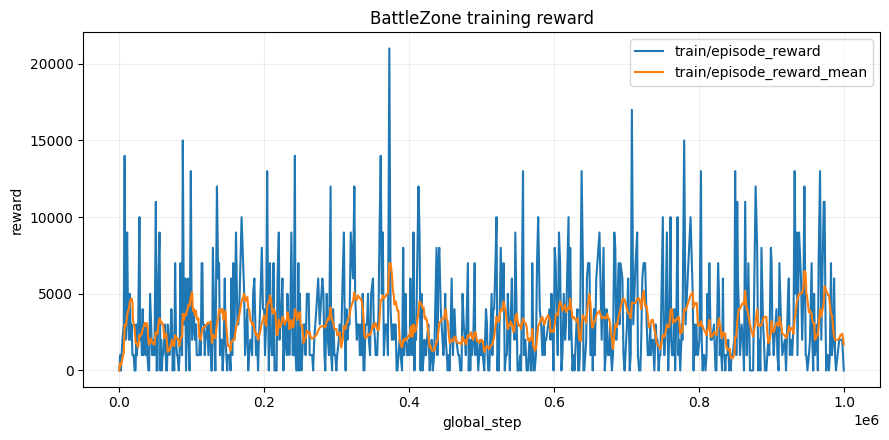

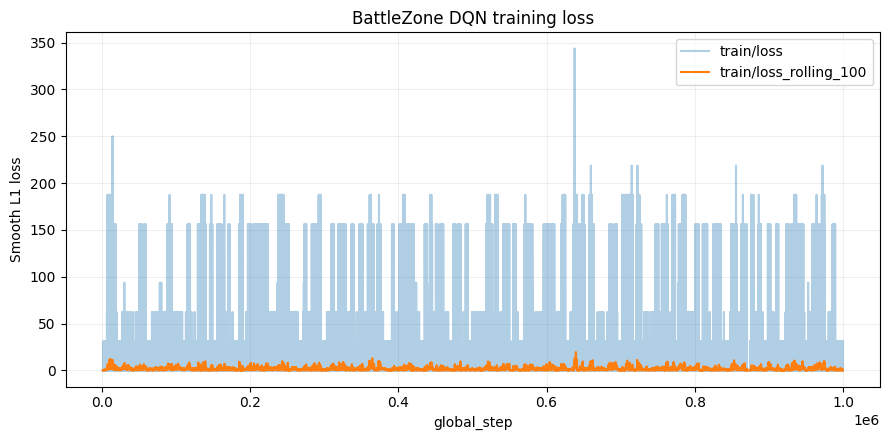

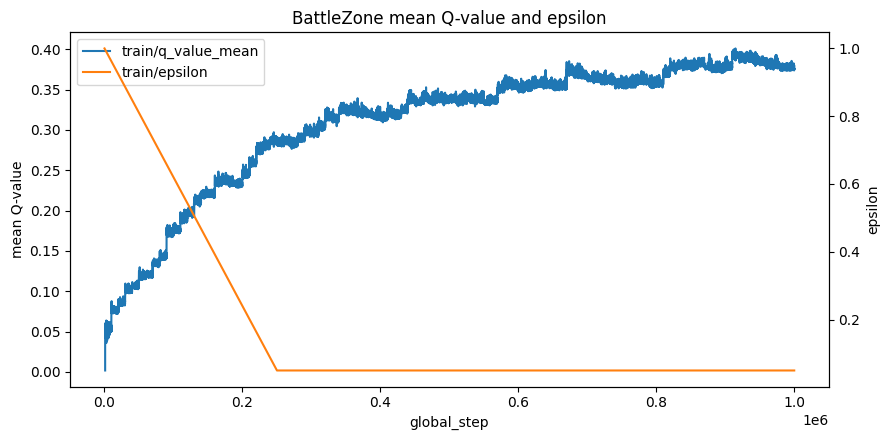

TENSORBOARD_REPORTING=PASS ['training_reward.png', 'training_loss.png', 'training_q_epsilon.png']


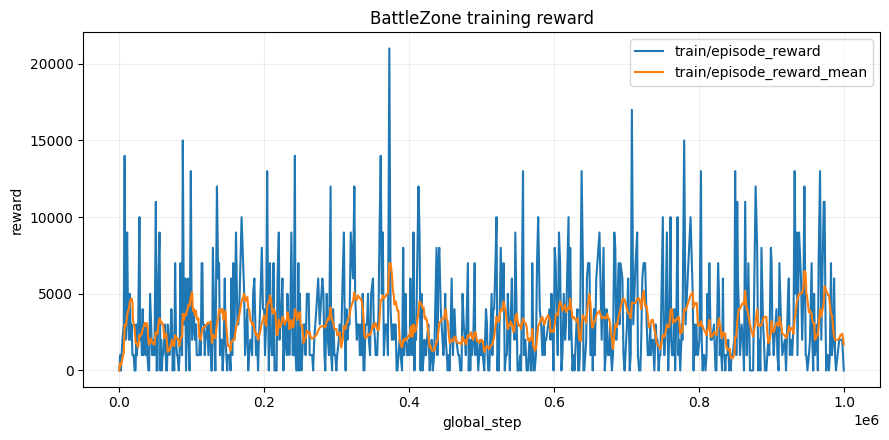

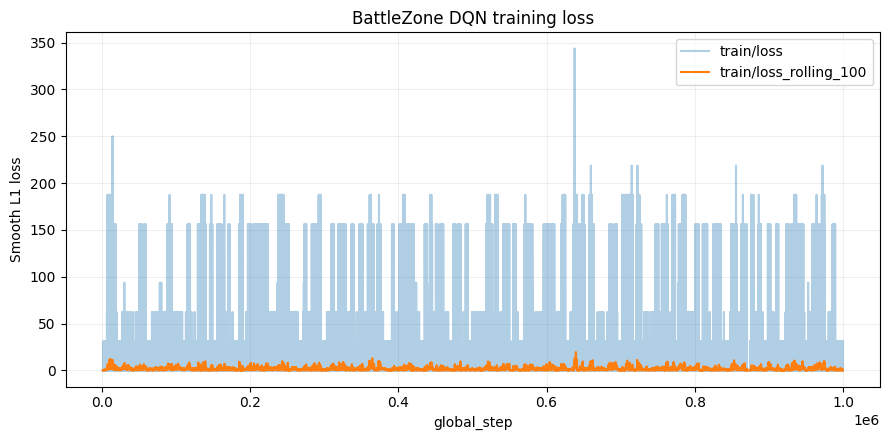

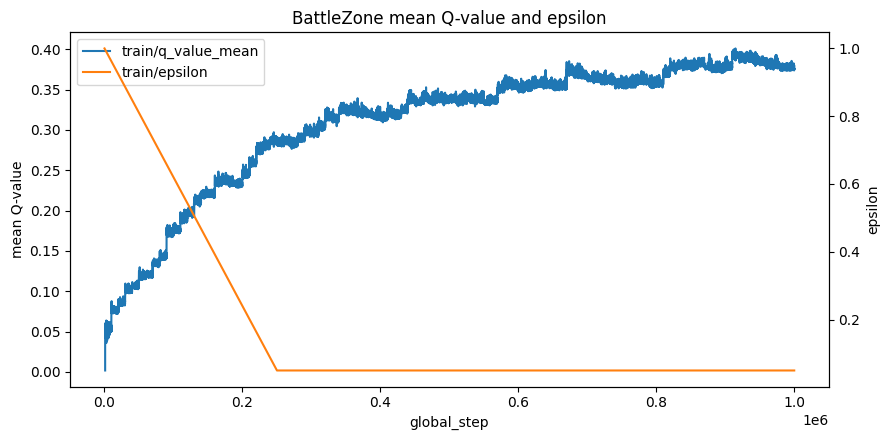

In [ ]:
# D: TensorBoard reporting from the real run, never from hand-written values.
from src.reporting import build_training_figures, load_tensorboard_scalars
if RUN_HU011B_DELIVERY:
    training_scalars = load_tensorboard_scalars(tensorboard_log_dir)
    training_figures = build_training_figures(training_scalars, delivery_paths["figures_dir"])
    for figure in training_figures.values():
        display(figure)
    print("TENSORBOARD_REPORTING=PASS", list(training_figures))

In [ ]:
# E–G: explicit intermediate-checkpoint video and freshly loaded final-model video.
from IPython.display import Video, display
from src.environment import create_battlezone_env
from src.model_artifact import load_checkpoint_inference_agent
from src.video import generate_post_training_demo_video, generate_training_process_demo_video
if RUN_HU011B_DELIVERY:
    intermediate_agent, intermediate_metadata = load_checkpoint_inference_agent(
        source_intermediate_checkpoint, config=delivery_config, map_location="cpu",
    )
    if intermediate_metadata.global_step != INTERMEDIATE_STEP:
        raise RuntimeError("Explicit intermediate checkpoint step mismatch.")
    intermediate_epsilon = max(0.05, 1.0 - (0.95 * INTERMEDIATE_STEP / 250_000))
    training_video = generate_training_process_demo_video(
        agent=intermediate_agent, env_factory=lambda: create_battlezone_env(config, mode="eval", seed=20261903, render_mode="rgb_array"),
        output_path=delivery_paths["training_video"], project_run_id=HU011B_RUN_ID,
        checkpoint_path=source_intermediate_checkpoint, checkpoint_step=INTERMEDIATE_STEP,
        final_step=HU011_FINAL_STEP, checkpoint_sha256=compute_sha256(source_intermediate_checkpoint),
        epsilon=intermediate_epsilon, seed=20261903, git_sha=TRAINING_GIT_SHA, fps=30, max_steps=2_000,
    )
    # Fresh load proves the video does not reuse a training-session object.
    post_agent, post_model_info = load_inference_model(
        delivery_paths["model"], map_location="cpu", expected_sha256=model_info.sha256,
        expected_project_run_id=HU011B_RUN_ID, expected_config=delivery_config,
    )
    post_video = generate_post_training_demo_video(
        agent=post_agent, env_factory=lambda: create_battlezone_env(config, mode="eval", seed=20261904, render_mode="rgb_array"),
        output_path=delivery_paths["post_training_video"], project_run_id=HU011B_RUN_ID,
        model_path=delivery_paths["model"], model_sha256=post_model_info.sha256,
        seed=20261904, fps=30, max_steps=2_000,
    )
    print("EVIDENCIA DEL PROCESO DE ENTRENAMIENTO")
    display(Video(str(training_video.path), embed=True))
    print("COMPORTAMIENTO APRENDIDO POST-ENTRENAMIENTO")
    display(Video(str(post_video.path), embed=True))

EVIDENCIA DEL PROCESO DE ENTRENAMIENTO


COMPORTAMIENTO APRENDIDO POST-ENTRENAMIENTO


In [ ]:
# H–I: persist a separate delivery manifest and evaluate the complete gate.
from src.delivery import evaluate_delivery_gate, write_delivery_manifest
from src.utils import get_git_commit
if RUN_HU011B_DELIVERY:
    delivery_manifest_path = write_delivery_manifest(
        path=delivery_paths["manifest"], project_run_id=HU011B_RUN_ID,
        training_git_sha=TRAINING_GIT_SHA, delivery_git_sha=get_git_commit(REPO_ROOT),
        source_final_checkpoint=source_final_checkpoint, source_intermediate_checkpoint=source_intermediate_checkpoint,
        tensorboard_logs=tensorboard_log_dir, delivery_model_path=delivery_paths["model"],
        persistent_model_path=persistent_model, local_project_model_path=local_project_model,
        figures={name: delivery_paths["figures_dir"] / name for name in training_figures},
        videos={"training_process": training_video.path, "post_training": post_video.path},
    )
    statuses = {
        "model": model_info.path.is_file(), "model_checksum": model_info.path.with_suffix(".pt.sha256").is_file(),
        "model_metadata": model_info.path.with_name("battlezone_dqn_model.metadata.json").is_file(), "round_trip_load": standalone_info.sha256 == model_info.sha256,
        "persistent_delivery_model": persistent_model.is_file(), "local_delivery_model": local_project_model.is_file(),
        "model_sha_consistency": compute_sha256(persistent_model) == compute_sha256(local_project_model) == model_info.sha256,
        "greedy_action": 0 <= post_agent.select_action(np.zeros((4,128,128,3), dtype=np.uint8), epsilon=0.0) < 18,
        "standalone_episode": post_video.steps > 0, "training_reward_figure": delivery_paths["training_reward"].is_file(),
        "training_loss_figure": delivery_paths["training_loss"].is_file(), "training_q_epsilon_figure": delivery_paths["training_q_epsilon"].is_file(),
        "training_video": training_video.path.is_file(), "training_video_metadata": training_video.metadata_path.is_file(),
        "post_training_video": post_video.path.is_file(), "post_training_video_metadata": post_video.metadata_path.is_file(),
        "delivery_manifest": delivery_manifest_path.is_file(), "run_lineage": model_info.metadata["project_run_id"] == HU011B_RUN_ID,
    }
    delivery_gate = evaluate_delivery_gate(statuses)
    print(json.dumps(delivery_gate, indent=2))
    print("HU011B_DELIVERY_GATE=" + delivery_gate["HU011B_DELIVERY_GATE"])

{
  "checks": {
    "model": true,
    "model_checksum": true,
    "model_metadata": true,
    "round_trip_load": true,
    "persistent_delivery_model": true,
    "local_delivery_model": true,
    "model_sha_consistency": true,
    "greedy_action": true,
    "standalone_episode": true,
    "training_reward_figure": true,
    "training_loss_figure": true,
    "training_q_epsilon_figure": true,
    "training_video": true,
    "training_video_metadata": true,
    "post_training_video": true,
    "post_training_video_metadata": true,
    "delivery_manifest": true,
    "run_lineage": true
  },
  "exploitation_reward": "PENDING_HU013",
  "HU011B_DELIVERY_GATE": "PASS"
}
HU011B_DELIVERY_GATE=PASS


## VERIFICACIÓN AUTÓNOMA DEL MODELO ENTREGADO

Esta sección no llama `train()` ni depende de objetos de la corrida HU011. Resuelve local-first y permite al profesor cargar el modelo en CPU o CUDA, producir una acción greedy y ejecutar un sanity episode.

In [ ]:
from src.model_artifact import compute_sha256, load_inference_model, resolve_delivery_model_path
VERIFY_RUN_ID = "battlezone-dqn-20260903-001628-b7c33d5-255e"
MODEL_PATH, MODEL_SOURCE = resolve_delivery_model_path(
    battlezone_dir=PROJECT_DIR, persistent_root=PERSISTENT_ROOT, project_run_id=VERIFY_RUN_ID,
)
verification_agent, verification_info = load_inference_model(
    MODEL_PATH, map_location=("cuda" if torch.cuda.is_available() else "cpu"),
    expected_sha256=compute_sha256(MODEL_PATH), expected_project_run_id=VERIFY_RUN_ID, expected_config=config,
)
verification_env = create_battlezone_env(config, mode="eval", seed=20261905)
verification_reward, verification_steps = 0.0, 0
try:
    verification_obs, _ = verification_env.reset(seed=20261905)
    greedy_action = verification_agent.select_action(verification_obs, epsilon=0.0)
    terminated = truncated = False
    while not (terminated or truncated) and verification_steps < 2_000:
        verification_obs, reward, terminated, truncated, _ = verification_env.step(verification_agent.select_action(verification_obs, epsilon=0.0))
        verification_reward += float(reward); verification_steps += 1
finally:
    verification_env.close()
print("MODEL_SOURCE:", MODEL_SOURCE)
print("MODEL_PATH:", MODEL_PATH)
print("MODEL_SHA256:", verification_info.sha256)
print("RUN_ID:", verification_info.metadata["project_run_id"])
print("ALGORITHM:", verification_info.metadata["algorithm"])
print("ENVIRONMENT:", verification_info.metadata["environment"]["env_id"])
print("STATE_SHAPE:", verification_info.metadata["state_shape"])
print("ACTION_DIM:", verification_info.metadata["action_dim"])
print("DEVICE:", verification_agent.device)
print("MODEL_LOAD=PASS")
print("GREEDY_ACTION=PASS", greedy_action)
print("INFERENCE_EPISODE=PASS", verification_reward, verification_steps)

MODEL_SOURCE: LOCAL_DELIVERY
MODEL_PATH: /content/reinforcement_learning_reto_1/3_BattleZone/battlezone_dqn_model.pt
MODEL_SHA256: 6817c4b1d5d6b34c8a49604f72feb77e399f3ab3b5d08cb98fdf12cb124b1302
RUN_ID: battlezone-dqn-20260903-001628-b7c33d5-255e
ALGORITHM: DQN
ENVIRONMENT: ALE/BattleZone-v5
STATE_SHAPE: [4, 128, 128, 3]
ACTION_DIM: 18
DEVICE: cuda
MODEL_LOAD=PASS
GREEDY_ACTION=PASS 11
INFERENCE_EPISODE=PASS 3000.0 1166


## Reporte técnico — BattleZone

- Algoritmo: DQN clásico (`reference_v1`).
- Entorno: `ALE/BattleZone-v5`; RGB 128×128, stack 4, radar preservado.
- Corrida HU011: `battlezone-dqn-20260903-001628-b7c33d5-255e`, 1.000.000 global steps, SHA `b7c33d5`, NVIDIA A100-SXM4-40GB, 4.700,8 segundos.
- Hiperparámetros y versiones: se muestran desde la configuración versionada y `runtime_info`; no se transcriben métricas manuales para las gráficas.
- Evidencias HU011B: modelo compacto, curvas TensorBoard y videos trazables al mismo run.

PENDING_HU013:
- mean reward de >=10 episodios;
- comparación con baseline aleatorio;
- figura final de recompensa de explotación;
- análisis de comportamiento basado en evaluación formal.

PENDING_HU014:
- conclusiones finales;
- consolidación editorial final.

## HU011C — Evaluación académica de explotación

Esta evaluación usa el modelo entrenado existente, ejecuta episodios completos con política greedy (`epsilon=0.0`) y no entrena ni modifica el agente.

In [ ]:
from src.model_artifact import load_checkpoint_inference_agent, load_inference_model
from src.training_run import resolve_long_training_config

EVALUATION_MODEL_PATH = PROJECT_DIR / "battlezone_dqn_model.pt"
evaluation_device = "cuda" if torch.cuda.is_available() else "cpu"
try:
    evaluation_agent, _ = load_inference_model(
        EVALUATION_MODEL_PATH, map_location=evaluation_device, expected_config=config,
    )
    evaluation_model_format = "inference_artifact"
except ValueError:
    evaluation_agent, _ = load_checkpoint_inference_agent(
        EVALUATION_MODEL_PATH, config=resolve_long_training_config(config),
        map_location=evaluation_device,
    )
    evaluation_model_format = "training_checkpoint"

print("EVALUATION_MODEL:", EVALUATION_MODEL_PATH)
print("EVALUATION_MODEL_FORMAT:", evaluation_model_format)
print("EVALUATION_DEVICE:", evaluation_device)

EVALUATION_MODEL: /content/reinforcement_learning_reto_1/3_BattleZone/battlezone_dqn_model.pt
EVALUATION_MODEL_FORMAT: inference_artifact
EVALUATION_DEVICE: cuda


In [ ]:
from src.evaluation import evaluate_agent

EVALUATION_EPISODES = 10
evaluation_results = evaluate_agent(
    evaluation_agent,
    env_factory=lambda: create_battlezone_env(config, mode="eval", render_mode=None),
    episodes=EVALUATION_EPISODES,
)
evaluation_table = pd.DataFrame(evaluation_results)
average_reward = sum(row["reward"] for row in evaluation_results) / len(evaluation_results)

display(evaluation_table)
print("EVALUATION_EPISODES:", len(evaluation_results))
print("AVERAGE_REWARD:", average_reward)

ModuleNotFoundError: No module named 'src.evaluation'

In [ ]:
from src.reporting import plot_exploitation_rewards

exploitation_figure = plot_exploitation_rewards(
    evaluation_results, status="ACADEMIC EVALUATION",
)
display(exploitation_figure)

## Análisis del comportamiento aprendido — completar por el estudiante

Describir aquí, a partir del video y de los episodios de evaluación, qué comportamientos lógicos se observan en el agente y cómo se relacionan con el DQN y los hiperparámetros utilizados.

## Conclusiones — completar por el estudiante

Redactar aquí la conclusión general basada en los resultados de entrenamiento y evaluación del agente BattleZone.